# CECS 427 - Assignment 2

## Resources (Required Reading)

* Lecture Slides: Strong and Weak Ties

* NetworkX Clustering: https://networkx.org/documentation/stable/reference/algorithms/clustering.html

* NetworkX Community: https://networkx.org/documentation/stable/reference/algorithms/community.html

* NetworkX Bridges: https://networkx.org/documentation/stable/reference/algorithms/bridges.html

---

## Part A – Triadic Closure & Clustering Coefficient on the Karate Club Graph

You will continue working with the Zachary Karate Club friendship network.

### **Using NetworkX**

1. **Clustering Coefficient:**

    * Compute and display the local clustering coefficient for every node using `nx.clustering()`

    * Identify the node(s) with the highest and lowest clustering coefficients

    * Compute the average clustering coefficient of the graph

2. **Triadic Closure:**

    * Count the total number of triangles in the graph using `nx.triangles()`

    * For node `0`, list all triangles it participates in (i.e., find all pairs of node 0's neighbors that are also connected to each other)

3. **Neighborhood Overlap:**

    * Implement a function `neighborhood_overlap(G, u, v)` that computes the neighborhood overlap of edge (u, v)

    * Compute and display the neighborhood overlap for edges `(0, 1)`, `(0, 31)`, and `(2, 33)`

    * Identify the edge with the lowest non-zero neighborhood overlap (this is the closest to a local bridge)



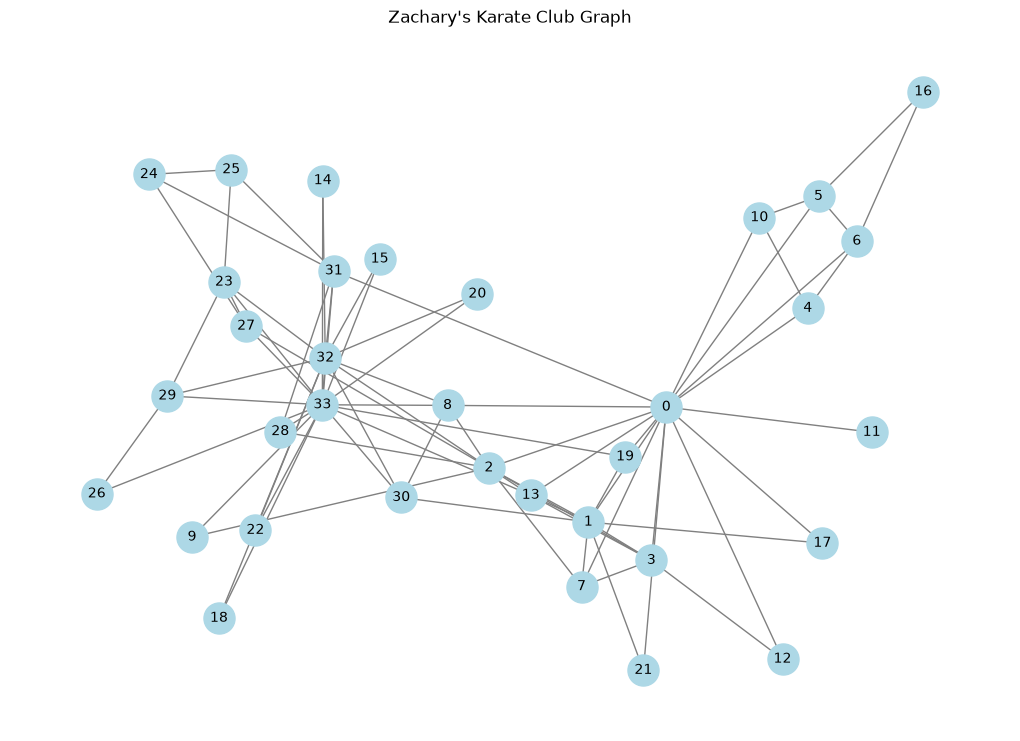

In [79]:
# Load and Draw the Karate Club Graph
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from collections import deque

G = nx.karate_club_graph()

plt.figure(figsize=(10, 7))
pos = nx.spring_layout(G, seed=126)
nx.draw(G, pos, with_labels=True, node_color='lightblue',
        node_size=500, font_size=10, edge_color='gray')
plt.title("Zachary's Karate Club Graph")
plt.show()


In [80]:
# A1 - Clustering Coefficient

# Compute the clustering coefficient for all nodes in graph G
# Round the value to 2 decimals
clustering_all_nodes = {node: round(value, 2) for node,value in nx.clustering(G).items()}

# Display the clustering for each node
print(clustering_all_nodes)

# Find nodes with min and max clustering value
min_val = min(clustering_all_nodes.values())
max_val = max(clustering_all_nodes.values())
min_nodes = [node for node, val in clustering_all_nodes.items() if val == min_val]
max_nodes = [node for node, val in clustering_all_nodes.items() if val == max_val]

# Display the found min and max nodes
print(f"Min value: {min_val}")
print(f"Nodes with min clustering values: {min_nodes}")
print(f"Max value: {max_val}")
print(f"Nodes with max clustering values: {max_nodes}")

# Calculate and display average
avg = round(nx.average_clustering(G), 2)
print(f"Average clustering coefficient of the graph: {avg}")

{0: 0.15, 1: 0.33, 2: 0.24, 3: 0.67, 4: 0.67, 5: 0.5, 6: 0.5, 7: 1.0, 8: 0.5, 9: 0, 10: 0.67, 11: 0, 12: 1.0, 13: 0.6, 14: 1.0, 15: 1.0, 16: 1.0, 17: 1.0, 18: 1.0, 19: 0.33, 20: 1.0, 21: 1.0, 22: 1.0, 23: 0.4, 24: 0.33, 25: 0.33, 26: 1.0, 27: 0.17, 28: 0.33, 29: 0.67, 30: 0.5, 31: 0.2, 32: 0.2, 33: 0.11}
Min value: 0
Nodes with min clustering values: [9, 11]
Max value: 1.0
Nodes with max clustering values: [7, 12, 14, 15, 16, 17, 18, 20, 21, 22, 26]
Average clustering coefficient of the graph: 0.57


In [81]:
# A2 - Triadic Closure: Triangles
nodes = list(G.nodes())
total_triangles = 0

# Count total number of triangles in the graph
for node in nodes:
  total_triangles += nx.triangles(G, nodes=node)

total_triangles = total_triangles // 3 # divide by 3 to avoid triple counting
print(f"Total number of triangles in the graph: {total_triangles}")

import itertools # used to generate combination of 2 nodes

# List of neighbors nodes of node 0
neighbors_of_node_0 = list(G.neighbors(0))

# Check each pair of nodes in the neighbor list to see if they have an edge
connected_neighbor_pairs = []
for n1,n2 in itertools.combinations(neighbors_of_node_0, 2):
  if G.has_edge(n1, n2):
    connected_neighbor_pairs.append((n1,n2))

print(f"Neighbors of {0} that are connected to each other:")
print(connected_neighbor_pairs)


Total number of triangles in the graph: 45
Neighbors of 0 that are connected to each other:
[(1, 2), (1, 3), (1, 7), (1, 13), (1, 17), (1, 19), (1, 21), (2, 3), (2, 7), (2, 8), (2, 13), (3, 7), (3, 12), (3, 13), (4, 6), (4, 10), (5, 6), (5, 10)]


In [82]:
# A3 - Neighborhood Overlap

# Implement function to compute the neighborhood overlap of the edge (u, v)
def compute_neighborhood_overlap(G, u, v) -> float:
    # Store the neighbors of each node
    neighbors_of_u = set(G.neighbors(u))
    neighbors_of_v = set(G.neighbors(v))

    # Get common neighbors and total surrounding neighbors
    common_neighbors = neighbors_of_u & neighbors_of_v
    total_neighbors = (neighbors_of_u | neighbors_of_v) - {u, v}

    # Avoid division by zero
    if len(total_neighbors) == 0:
        return 0

    return len(common_neighbors) / len(total_neighbors)


# Compute and display the neighborhood overlap for edges (0, 1), (0, 31), and (2, 33)
neighborhood_overlap_0_1 = compute_neighborhood_overlap(G, 0, 1)
neighborhood_overlap_0_31 = compute_neighborhood_overlap(G, 0, 31)
neighborhood_overlap_2_33 = compute_neighborhood_overlap(G, 2, 33)

print("Neighborhood overlap values for the edges:")
print(f"(0, 1): {neighborhood_overlap_0_1:.2f}")
print(f"(0, 31): {neighborhood_overlap_0_31:.2f}")
print(f"(2, 33): {neighborhood_overlap_2_33:.2f}")


# Identify the edge with the lowest non-zero neighborhood overlap
# (closest to a local bridge)
lowest_overlap = float('inf')
lowest_overlap_u = -1
lowest_overlap_v = -1

# Loop through all edges (u, v)
for u, v in G.edges():
    current_overlap = compute_neighborhood_overlap(G, u, v)

    if current_overlap < lowest_overlap and current_overlap > 0:
        lowest_overlap = current_overlap
        lowest_overlap_u = u
        lowest_overlap_v = v

print(
    f"The edge with lowest non-zero neighborhood overlap is "
    f"({lowest_overlap_u}, {lowest_overlap_v}): {lowest_overlap:.2f}"
)

Neighborhood overlap values for the edges:
(0, 1): 0.44
(0, 31): 0.00
(2, 33): 0.29
The edge with lowest non-zero neighborhood overlap is (2, 32): 0.05


---

## Part B – Bridges, Local Bridges & Strong/Weak Tie Analysis

### **Using NetworkX and your own implementations**

1. **Bridges:**

    * Use `nx.bridges()` to find all bridges in the Karate Club Graph

    * Draw the graph highlighting any bridges in red

2. **Local Bridges (from scratch):**

    * Implement a function `find_local_bridges(G)` that returns all local bridges and their spans

    * A local bridge is an edge whose removal increases the distance between its endpoints to strictly > 2 (equivalently, its endpoints share no common neighbors)

    * The span of a local bridge is the shortest path distance between u and v after removing the edge (u, v).

    * Display all local bridges and their spans

3. **Strong/Weak Tie Labeling:**

    * Label edges as **strong** or **weak** based on neighborhood overlap: if overlap >= median overlap, label as strong; otherwise weak

    * Draw the graph with strong ties as thick solid lines and weak ties as thin dashed lines



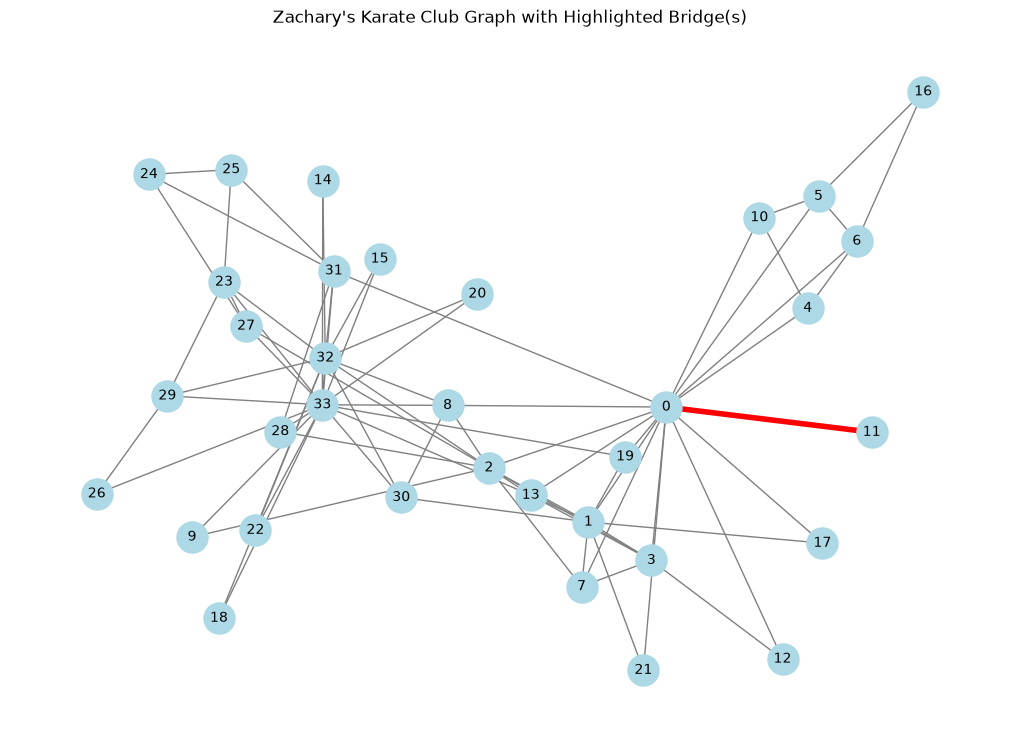

In [83]:
# B1 - Bridges
# Saving the bridge(s) in the graph
bridges = list(nx.bridges(G))

# Draw graph highlighting the bridges
plt.figure(figsize=(10, 7))
pos = nx.spring_layout(G, seed=126)
nx.draw(G, pos, with_labels=True, node_color='lightblue',
        node_size=500, font_size=10, edge_color='gray', )

# Overlay just the highlighted edge on top
nx.draw_networkx_edges(
    G,
    pos,
    edgelist=bridges,
    edge_color='red',
    width=4.0
)

plt.title("Zachary's Karate Club Graph with Highlighted Bridge(s)")
plt.show()


In [84]:
# B2 - Local Bridges (from scratch)

# Implement a function `find_local_bridges(G)` that returns all local bridges and their spans

def find_local_bridges(G):
    '''Given a graph G, returns all local bridges and their spans'''
    local_bridges = []

    for u, v in G.edges():
        # Check if there are common neighbors between u and v
        neighbors_u = set(G.neighbors(u))
        neighbors_v = set(G.neighbors(v))

        # If no common neighbors, it may be a local bridge
        if len(neighbors_u & neighbors_v) == 0:
            # The span of a local bridge is the shortest path distance between u and v after removing the edge (u, v).
            G.remove_edge(u, v)
            try:
                span = nx.shortest_path_length(G, source=u, target=v)
                # A local bridge is an edge whose removal increases the distance between its endpoints to strictly > 2 (equivalently, its endpoints share no common neighbors)
                if span > 2:
                    local_bridges.append((u, v, span))
            except nx.NetworkXNoPath:
                # If there's no path between u and v after removing the edge, it's a local bridge with infinite span
                local_bridges.append((u, v, float('inf')))
            finally:
                # Add the removed edge back to graph
                G.add_edge(u, v)

    return local_bridges

# Display all local bridges and their spans
local_bridges = find_local_bridges(G)
print("Local bridges and their spans:")
for u, v, span in local_bridges:
    print(f"\tEdge ({u}, {v}), Span = {span}")

Local bridges and their spans:
	Edge (0, 11), Span = inf
	Edge (0, 31), Span = 3
	Edge (1, 30), Span = 3
	Edge (2, 9), Span = 3
	Edge (2, 27), Span = 3
	Edge (2, 28), Span = 3
	Edge (9, 33), Span = 3
	Edge (13, 33), Span = 3
	Edge (19, 33), Span = 3
	Edge (23, 25), Span = 3
	Edge (24, 27), Span = 3


Median neighborhood overlap: 0.129
Edge: (0, 1) Overlap: 0.438 Tie: Strong
Edge: (0, 2) Overlap: 0.263 Tie: Strong
Edge: (0, 3) Overlap: 0.333 Tie: Strong
Edge: (0, 4) Overlap: 0.133 Tie: Strong
Edge: (0, 5) Overlap: 0.125 Tie: Weak
Edge: (0, 6) Overlap: 0.125 Tie: Weak
Edge: (0, 7) Overlap: 0.2 Tie: Strong
Edge: (0, 8) Overlap: 0.056 Tie: Weak
Edge: (0, 10) Overlap: 0.133 Tie: Strong
Edge: (0, 12) Overlap: 0.067 Tie: Weak
Edge: (0, 13) Overlap: 0.188 Tie: Strong
Edge: (0, 17) Overlap: 0.067 Tie: Weak
Edge: (0, 19) Overlap: 0.062 Tie: Weak
Edge: (0, 21) Overlap: 0.067 Tie: Weak
Edge: (0, 11) Overlap: 0.0 Tie: Weak
Edge: (0, 31) Overlap: 0.0 Tie: Weak
Edge: (1, 2) Overlap: 0.308 Tie: Strong
Edge: (1, 3) Overlap: 0.444 Tie: Strong
Edge: (1, 7) Overlap: 0.375 Tie: Strong
Edge: (1, 13) Overlap: 0.333 Tie: Strong
Edge: (1, 17) Overlap: 0.125 Tie: Weak
Edge: (1, 19) Overlap: 0.111 Tie: Weak
Edge: (1, 21) Overlap: 0.125 Tie: Weak
Edge: (1, 30) Overlap: 0.0 Tie: Weak
Edge: (2, 3) Overlap: 0.4 

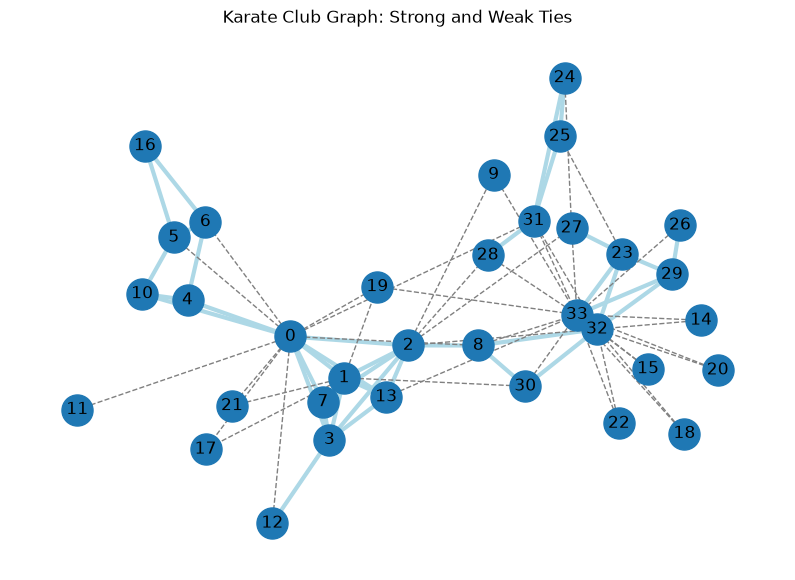

In [85]:
# B3 - Strong/Weak Tie Labeling

# Store the overlap value for each edge
edge_overlaps = {}

for u, v in G.edges():
    overlap = compute_neighborhood_overlap(G, u, v)
    edge_overlaps[(u, v)] = overlap

# Find the median overlap value
overlap_values = list(edge_overlaps.values())
median_overlap = np.median(overlap_values)

print("Median neighborhood overlap:", round(median_overlap, 3))

# Separate edges into strong and weak ties
strong_edges = []
weak_edges = []

for edge, overlap in edge_overlaps.items():
    # Label edges as **strong** or **weak** based on neighborhood overlap:
    # if overlap >= median overlap, label as strong; otherwise weak

    if overlap >= median_overlap:
        strong_edges.append(edge)
        label = "Strong"
    else:
        weak_edges.append(edge)
        label = "Weak"

    print("Edge:", edge, "Overlap:", round(overlap, 3), "Tie:", label)

# Create positions for the nodes
pos = nx.spring_layout(G, seed=126)

# Draw the nodes and labels
plt.figure(figsize=(10, 7))
nx.draw_networkx_nodes(G, pos, node_size=500)
nx.draw_networkx_labels(G, pos)

#Draw the graph with strong ties as thick solid lines and weak ties as thin dashed lines
nx.draw_networkx_edges(G, pos, edgelist=strong_edges, width=3, style="solid", edge_color='lightblue')
nx.draw_networkx_edges(G, pos, edgelist=weak_edges, width=1, style="dashed", edge_color="gray")

plt.title("Karate Club Graph: Strong and Weak Ties")
plt.axis("off")
plt.show()

---

## Part C – Girvan-Newman Divisive Method

Implement the **Girvan-Newman divisive method** from scratch to detect communities in the Karate Club Graph.

### **Requirements**

1. **Implement BFS-based edge betweenness computation:**

    * For each node u, perform a BFS from u

    * Count the number of shortest paths from u to every other node

    * Working bottom-up from the BFS tree, compute the flow contribution of each edge

    * Sum contributions from all source nodes, then divide by 2 (each pair is counted twice)

2. **Implement the Girvan-Newman algorithm:**

    * Repeatedly: compute edge betweenness → remove edge(s) with highest betweenness → check number of components

    * Stop when the graph splits into **2 communities**

3. **Visualize and compare:**

    * Draw the graph colored by detected communities

    * Compare your result with NetworkX's built-in `girvan_newman`


In [86]:
# C1 - BFS-based Edge Betweenness Computation (from scratch)

def compute_betweenness_from_source(G, source_node):
    # Distance from the source to each node
    distance = {node: -1 for node in G.nodes()}

    # Number of shortest paths from the source to each node
    num_paths = {node:0 for node in G.nodes()}

    # Parents of each node in the BFS shortest-path structure
    parents = {node: [] for node in G.nodes()}

    # Order in which nodes are visited by BFS
    # Later, we will reverse it to calculate flow from bottom to top
    bfs_order = []

    # Initialize the source node
    distance[source_node] = 0
    num_paths[source_node] = 1


    queue = deque([source_node])

    # Perform BFS
    while queue:
        current_node = queue.popleft()
        bfs_order.append(current_node)

        for neighbor in G.neighbors(current_node):
            # If this node has never been visited, then we found its shortest distance
            if distance[neighbor] == -1:
                distance[neighbor] = distance[current_node] + 1
                queue.append(neighbor)

            # If going from current_node to neighbor is part of the shortest path,
            # current node is one of neighbor's parents
            if distance[neighbor] == distance[current_node] + 1:
                parents[neighbor].append(current_node)

                # Every shortest path that reaches current_node
                # can also reach neighbor through this edge
                num_paths[neighbor] += num_paths[current_node]

    # Calculate flow fropm bottom to top
    # Every node begins with flow 1 for itself
    node_flow = {node: 1.0 for node in G.nodes()}

    # Store edge-flow contribution from this source
    edge_flow = {}

    # Work backward through the BFS
    for node in reversed(bfs_order):
        # The source has no parents, so we can skip it
        if node == source_node:
            continue

        # Send this node's flow to each of its parents
        for parent in parents[node]:
            # Fraction of shortest paths to this node that pass through this parent
            path_fraction = (num_paths[parent] / num_paths[node])

            # Flow assigned to the edge
            contribution = node_flow[node] * path_fraction

            # Store undirected edges consistently
            edge = tuple(sorted((parent, node)))

            edge_flow[edge] = (edge_flow.get(edge, 0.0) + contribution)

            # The parent also receives this flow, which will later be passed further upward
            node_flow[parent] += contribution

    return edge_flow


# Final edge betweenness for every edge in the graph
def compute_edge_betwenness(G):
    # Start every edge at 0
    total_betweenness = {tuple(sorted(edge)): 0.0 for edge in G.edges()}

    # Repeat the BFS/flow computation using every node as a source
    for source_node in G.nodes():
        source_contributions = compute_betweenness_from_source(G, source_node)

        # Add this source's contributions to the totals
        for edge, value in source_contributions.items():
            total_betweenness[edge] += value

    # Since graph is undirected, every pair is counted twice
    # Divide contributions by 2
    for edge in total_betweenness:
        total_betweenness[edge] /= 2

    return total_betweenness


# Compute edge betweenness for the Karate Club Graph
edge_betweenness = compute_edge_betwenness(G)

for edge, value in edge_betweenness.items():
    print(f"{edge}: {value:.4f}")

(0, 1): 14.1667
(0, 2): 43.6389
(0, 3): 11.5000
(0, 4): 29.3333
(0, 5): 43.8333
(0, 6): 43.8333
(0, 7): 12.8024
(0, 8): 41.6484
(0, 10): 29.3333
(0, 12): 26.1000
(0, 13): 23.7706
(0, 17): 22.5095
(0, 19): 25.7706
(0, 21): 22.5095
(0, 11): 33.0000
(0, 31): 71.3929
(1, 2): 13.0333
(1, 3): 4.3333
(1, 7): 4.1643
(1, 13): 6.9595
(1, 17): 10.4905
(1, 19): 8.2095
(1, 21): 10.4905
(1, 30): 18.1095
(2, 3): 12.5833
(2, 7): 14.1452
(2, 8): 5.1476
(2, 13): 4.2810
(2, 32): 38.7016
(2, 9): 17.2810
(2, 27): 23.1087
(2, 28): 12.7810
(3, 7): 1.8881
(3, 12): 6.9000
(3, 13): 8.3714
(4, 6): 2.6667
(4, 10): 1.6667
(5, 6): 1.6667
(5, 10): 2.6667
(5, 16): 16.5000
(6, 16): 16.5000
(8, 30): 5.5000
(8, 32): 17.0778
(8, 33): 22.6849
(9, 33): 16.6143
(13, 33): 38.0492
(14, 32): 13.5111
(14, 33): 19.4889
(15, 32): 13.5111
(15, 33): 19.4889
(18, 32): 13.5111
(18, 33): 19.4889
(19, 33): 33.3135
(20, 32): 13.5111
(20, 33): 19.4889
(22, 32): 13.5111
(22, 33): 19.4889
(23, 27): 5.9111
(23, 29): 3.7333
(23, 32): 12.5333

In [87]:
# C2 - Girvan-Newman Algorithm (from scratch)

def girvan_newman_algorithm(G, num_desired_components):
    # Initialize new graph so we don't change the original graph
    new_G = G.copy()

    # Check if graphs current number of components is the desired one
    # If yes, keep cutting edges. If not, end loop and return
    while (nx.number_connected_components(new_G) < num_desired_components):
        # Calculate current betweenness values
        current_edge_betweenness = compute_edge_betwenness(new_G)

        # Get highest betweenness value (we don't need to store the value itself)
        highest_edge = max(current_edge_betweenness, key=current_edge_betweenness.get)

        # Cut the edge that corresponds to the tuple with highest value
        new_G.remove_edge(*highest_edge)

        #print(f"Removed edge: {highest_edge} ")

    return new_G

# Implement the algorithm in our graph until we reach 2 different communities
num_desired_components = 2

new_graph = girvan_newman_algorithm(G, num_desired_components)
#print(nx.number_connected_components(new_graph))

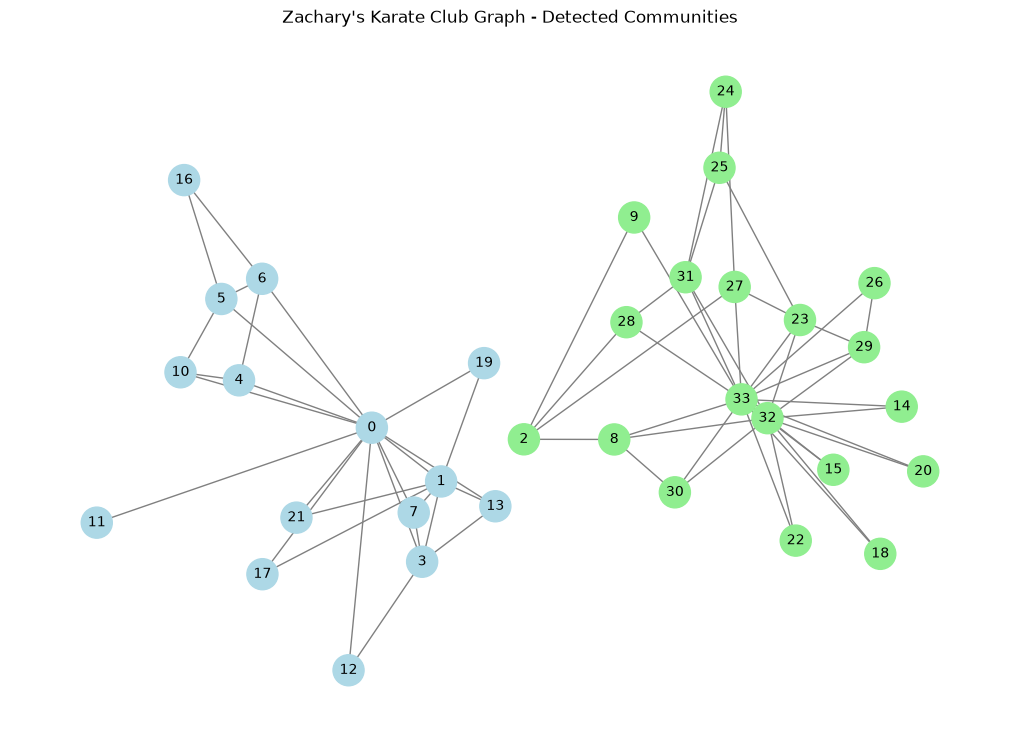

In [88]:
# C3 - Visualize detected communities

# Get the different communities from our new partitioned graph
communities = list(nx.connected_components(new_graph))

# Assign a color to each node depending on its community
node_colors = {}

colors = ['lightblue', 'lightgreen']

for i, community in enumerate(communities):
    for node in community:
        node_colors[node] = colors[i]

# Create the color list in the same order as the graph's nodes
color_list = [node_colors[node] for node in new_graph.nodes()]

# Draw the graph
plt.figure(figsize=(10, 7))
pos = nx.spring_layout(G, seed=126)
nx.draw(new_graph, pos, with_labels=True, node_color=color_list, 
        node_size=500, font_size=10, edge_color='gray')
plt.title(f"Zachary's Karate Club Graph - Detected Communities")
plt.show()


Our Algorithm communities:
[{0, 1, 3, 4, 5, 6, 7, 10, 11, 12, 13, 16, 17, 19, 21}, {2, 8, 9, 14, 15, 18, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33}]

NetworkX's Girvan-Newman Algorithm communities:
({0, 1, 3, 4, 5, 6, 7, 10, 11, 12, 13, 16, 17, 19, 21}, {2, 8, 9, 14, 15, 18, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33})

Same partition: True


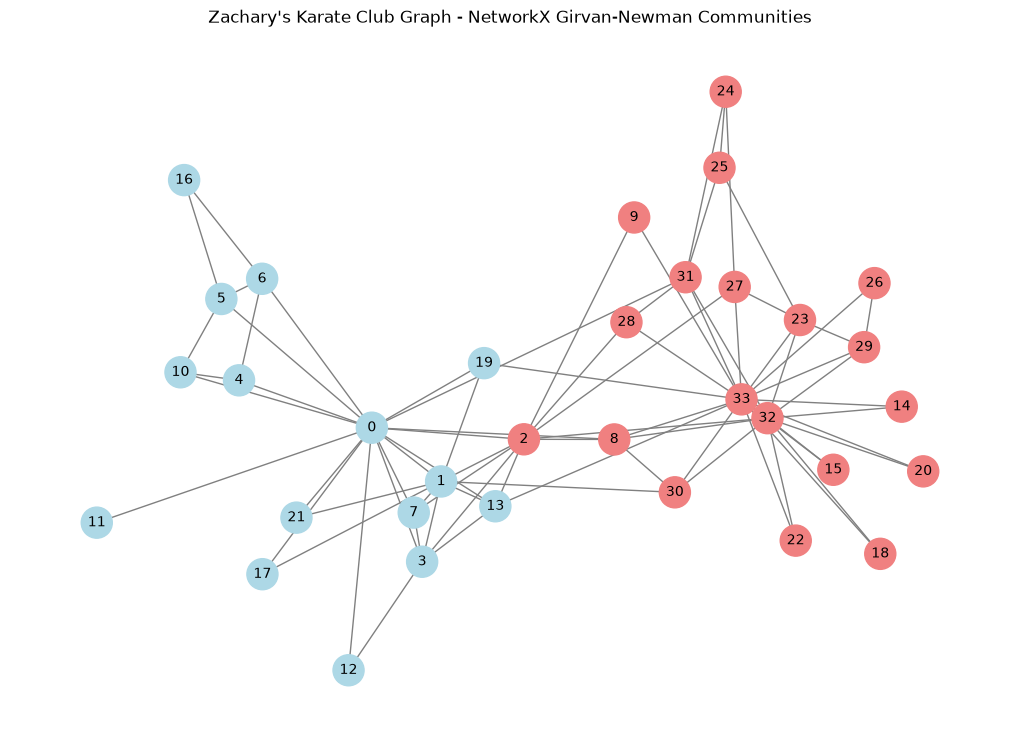

In [ ]:
# Compare with NetworkX's Girvan-Newman

# Get the communities iterator from the built-in algorithm
communities_generator = nx.community.girvan_newman(G)
# Split into two communities and print
nx_communities = next(communities_generator)

# Compare to ours (earlier it was declared as 'communities') and print both
print("Our Algorithm communities:")
print(communities)

print("\nNetworkX's Girvan-Newman Algorithm communities:")
print(nx_communities)

# Use a set comparison to check if the partitions are equal or not
our_partition = {frozenset(c) for c in communities}
nx_partition = {frozenset(c) for c in nx_communities}
print("\nSame partition:", our_partition == nx_partition)